In [29]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import sqlite3
import seaborn as sns
import numpy as np
import re as re
from matplotlib import pyplot as plt

In [5]:
# load dataset
con = sqlite3.connect('C:/Users/ilhan/Desktop/EGT309-CAIEProj-GrpM/final_bmarket.db')

In [8]:
cursor = con.cursor()
query = "SELECT name FROM sqlite_master WHERE type='table';"
cursor.execute(query)
table_names = [row[0] for row in cursor.fetchall()]

In [9]:
print("Tables in the database:", table_names)

Tables in the database: ['df_model_table']


In [12]:
df = pd.read_sql_query("SELECT * FROM df_model_table", con)
df.head()

,client_id,age,campaign_calls,previous_contact_days,occupation_impute_stage,marital_impute_stage,education_impute_stage,subscription_status_encoded,credit_default_enc,housing_loan_enc,...,education_level_basic_9y,education_level_high_school,education_level_illiterate,education_level_professional_course,education_level_university_degree,contact_method_telephone,age_group_26-35,age_group_36-50,age_group_51-65,age_group_65+
0,32885,57,1,NaN,None,None,None,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,3170,55,2,NaN,C,None,A,0,0,1,...,0,0,0,0,1,1,0,0,1,0
2,32207,33,1,NaN,None,None,None,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,9404,36,4,NaN,None,None,None,0,0,0,...,0,1,0,0,0,1,0,1,0,0
4,14021,27,2,NaN,None,None,None,0,0,-1,...,0,1,0,0,0,0,1,0,0,0


In [19]:
target_column = "subscription_status_encoded"    

X = df.drop(columns=[target_column])
y = df[target_column]

# find all object/string columns
obj_cols = X.select_dtypes(include=["object"]).columns
print("Object columns:", obj_cols.tolist())

# one-hot encode them
X = pd.get_dummies(X, columns=obj_cols, drop_first=True)

Object columns: ['occupation_impute_stage', 'marital_impute_stage', 'education_impute_stage']


In [32]:
print("Unique values:", df[target_column].unique())
print("Number of unique values:", df[target_column].nunique())
print(df[target_column].value_counts())
# to see if it is binary or multi-class classification

Unique values: [0 1]
Number of unique values: 2
subscription_status_encoded
0    36548
1     4640
Name: count, dtype: int64


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # for classification
)

print(X_train.shape, X_test.shape)


(32950, 37) (8238, 37)


In [ ]:
# xgbosst classifier
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",  # binary classification since nunique() is 2
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [22]:
# predictions
y_pred = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average="binary")) 

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8963340616654528
F1-score: 0.353030303030303

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7310
           1       0.59      0.25      0.35       928

    accuracy                           0.90      8238
   macro avg       0.75      0.61      0.65      8238
weighted avg       0.88      0.90      0.88      8238



In [25]:
# hyperparameter tuning with GridSearchCV
param_grid = {
    "max_depth": [4, 6, 8],
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

xgb_base = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",   
    cv=3,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nTest scores with best model:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best, average="binary"))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best CV score: 0.3665347749093681

Test scores with best model:
Accuracy: 0.8945132313668366
F1-score: 0.35772357723577236


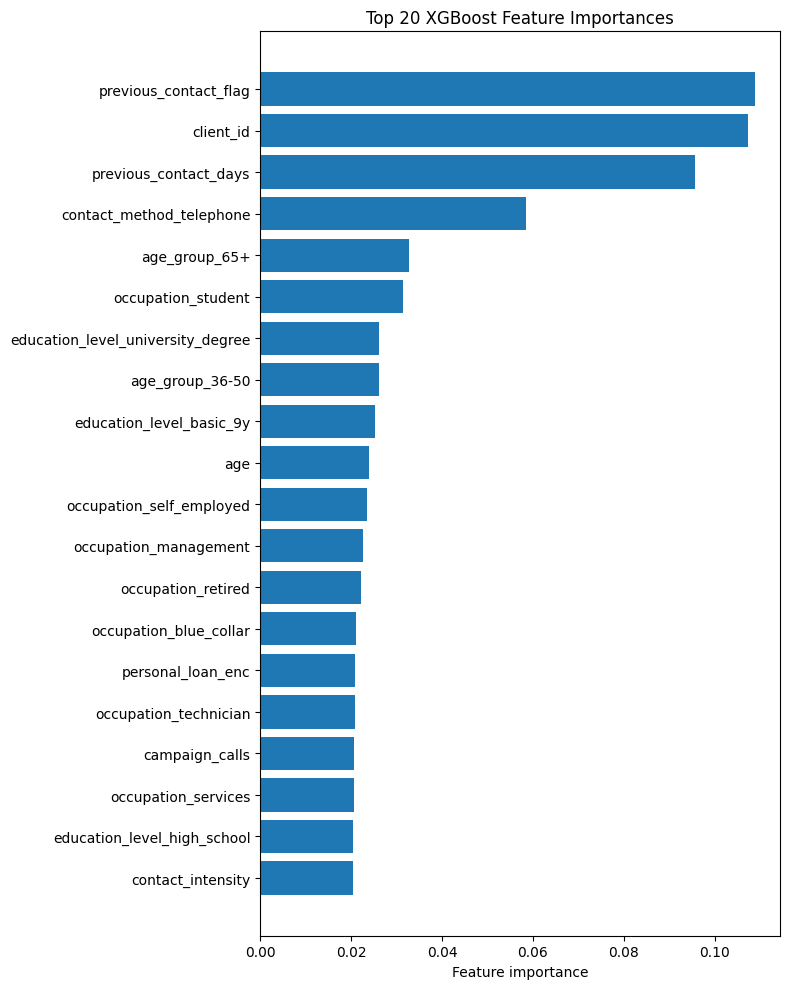

In [26]:
# feature importance plot
importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices][::-1])
plt.yticks(range(len(indices)), X.columns[indices][::-1])
plt.xlabel("Feature importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()


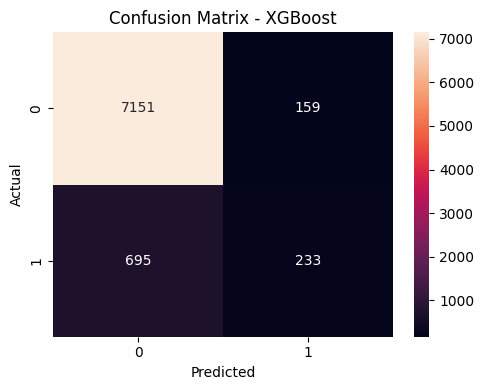

In [30]:
# heatmap of confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()
